# ANCOM-BC: differential abundance by fungal colonization score (16S)

**Comparison**: `fungal_colonization_score` 0 (low) vs 4+5 (high)  
**Subset**: `unbagged_flower` only — score 4+5 never occurs in bagged (structural confound)  
**Filters**: same as `01_dim_reduction` — prevalence >= 10%, min_total >= 500  
**Covariates**: `group + farm_id` (no random effects in skbio ancombc — tree_id excluded)  
**Reference level**: low (score=0)

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import biom
from skbio.stats.composition import ancombc, struc_zero

ROOT     = Path('..').resolve()
BIOM_DIR = ROOT / 'results' / 'biom'
DATA_DIR = ROOT / 'data'
FIG_DIR  = ROOT / 'results' / 'figures' / 'ancombc'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Threshold for prevalence filtration (minimum fraction of samples in which a feature is present)
PREV_THRESHOLD = 0.05
# Threshold for abundance filtration (minimum total count across all samples)
MIN_TOTAL      = 500
FDR_ALPHA      = 0.05

print('OK')


OK


In [2]:
# ── Load counts + metadata + taxonomy ────────────────────────────────────────
tbl = biom.load_table(str(BIOM_DIR / 'cfm_16s_bacteria_biosamples_feature-table.biom'))
counts_raw = tbl.to_dataframe(dense=True)  # ASVs x samples

meta = pd.read_csv(DATA_DIR / 'sample_metadata_with_microscopy.txt',
                   sep='\t', index_col=0, dtype=str)
meta['fungal_colonization_score'] = pd.to_numeric(
    meta['fungal_colonization_score'], errors='coerce'
)

tax_df = pd.read_csv(BIOM_DIR / 'cfm_16s_bacteria_biosamples_taxonomy.tsv',
                     sep='\t', index_col=0)

def genus_label(asv_id):
    if asv_id not in tax_df.index:
        return asv_id[:8]
    taxon = str(tax_df.loc[asv_id].iloc[0])
    for prefix in ('g__', 'f__', 'o__'):
        for part in reversed(taxon.split(';')):
            name = part.strip().removeprefix(prefix).strip()
            if part.strip().startswith(prefix) and name:
                return f'{name} [{asv_id[:6]}]'
    return asv_id[:8]

# ── 1. Subset first: unbagged_flower, score 0 vs 4+5 ─────────────────────────
meta_sub = meta[
    (meta['sample_type'] == 'unbagged_flower') &
    (meta['fungal_colonization_score'].isin([0, 4, 5]))
].copy()
meta_sub['group'] = pd.Categorical(
    meta_sub['fungal_colonization_score'].apply(lambda x: 'high' if x >= 4 else 'low'),
    categories=['low', 'high'], ordered=False
)

shared       = meta_sub.index.intersection(counts_raw.columns)
meta_sub     = meta_sub.loc[shared]
counts_sub   = counts_raw[shared]

# ── 2. Filter WITHIN subset ───────────────────────────────────────────────────
n_sub      = counts_sub.shape[1]
prev_sub   = (counts_sub > 0).sum(axis=1) / n_sub
table_sub  = counts_sub[
    (prev_sub >= PREV_THRESHOLD) & (counts_sub.sum(axis=1) >= MIN_TOTAL)
].T  # samples x ASVs

print(f'Subset: {n_sub} samples  (low={( meta_sub.group=="low").sum()}, high={(meta_sub.group=="high").sum()})')
print(f'ASVs after filter within subset: {table_sub.shape[1]}')
print(f'  (global filter gave: {((( counts_raw > 0).sum(axis=1) / counts_raw.shape[1]) >= PREV_THRESHOLD).sum()} ASVs)')
print(f'farm_id x group:')
print(meta_sub.groupby(['farm_id','group']).size().unstack(fill_value=0))


Subset: 71 samples  (low=43, high=28)
ASVs after filter within subset: 144
  (global filter gave: 580 ASVs)
farm_id x group:
group    low  high
farm_id           
ib         6     1
kk         4     6
mt        10     1
sa         9     4
vi         1     5
vr         8     7
yb         5     4


In [3]:
# ── Structural zeros: features absent in ALL samples of one group ─────────────
# neg_lb=True recommended when n_per_group > ~20
sz = struc_zero(
    table    = table_sub,
    metadata = meta_sub[['group']],
    grouping = 'group',
    neg_lb   = True
)

# sz is features x groups boolean DataFrame; True = structural zero in that group
sz_any = sz.any(axis=1)  # features with structural zero in at least one group
print(f'Features with structural zeros: {sz_any.sum()}  (in low: {sz["low"].sum()}, in high: {sz["high"].sum()})')
if sz_any.sum() > 0:
    print(sz[sz_any])

# Remove them before ancombc — they cause log(0) issues
table_sub_filt = table_sub.loc[:, ~sz_any]
print(f'\nASVs passed to ancombc: {table_sub_filt.shape[1]}  (removed {sz_any.sum()})')


Features with structural zeros: 50  (in low: 21, in high: 41)
                                   high    low
231a9f90207df93c921a4de2eee32b9e   True  False
49188348ee1ba23ae9ee381bf95f6055  False   True
1b38a76e014d6e20219ec6bd30d2d355   True  False
67024a134e5f00e50b1ab01f3e384a31  False   True
dc30e3f9ea29f378a9eb85a84d1f7c51   True  False
6d9f83b5edafa4d404ef4f1bd425844f  False   True
caf3afb56d45f4f3d2b10acad489d41a  False   True
8d02ce24e5e4d48f193d84dbd7c647cb   True   True
7d58b73b13de6e7980febf7dd1a7fe76   True   True
b7c93aea4a75d7a5977f5382e3b4dea3   True  False
b5c8ed4496d79b916859402cdf11f0a7   True  False
fe563024b5725bd4b2c6507bc58f1ee2   True  False
cd8f395b2c0593b13fec6c874f4f563b  False   True
abd8191a1aed3a1a6e8a04a36a6dcfc4   True  False
c83dc3acf548e5485ebe04d1efc1f71d  False   True
86d6db0b6e15510fa5d27ceae8fd5e0d   True  False
48a2b88954f50c7725818c063187b794   True  False
69179c4a6011d0c9d30036cf18626520   True  False
0c5d2114ee9993714e590b3f7cb4e9ef   True  Fals

In [4]:
# ── ANCOM-BC ──────────────────────────────────────────────────────────────────
# +1 pseudocount required — ancombc needs strictly positive values
# Returns DataFrame with MultiIndex (FeatureID, Covariate)
result = ancombc(
    table     = table_sub_filt + 1,
    metadata  = meta_sub[['group', 'farm_id']],
    formula   = 'group + farm_id',
    p_adjust  = 'fdr_bh',
    alpha     = FDR_ALPHA,
)

# Extract group[T.high] rows — low is reference, high is the comparison
res_group = result.xs('group[T.high]', level='Covariate').copy()
res_group['label'] = [genus_label(i) for i in res_group.index]

n_sig    = res_group['Signif'].sum()
enriched = (res_group['Signif'] & (res_group['Log2(FC)'] > 0)).sum()
depleted = (res_group['Signif'] & (res_group['Log2(FC)'] < 0)).sum()
print(f'Significant (FDR < {FDR_ALPHA}): {n_sig}  '
      f'(enriched in high: {enriched},  depleted: {depleted})')
res_group[res_group['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


Significant (FDR < 0.05): 0  (enriched in high: 0,  depleted: 0)


,label,Log2(FC),SE,W,pvalue,qvalue
FeatureID,,,,,,


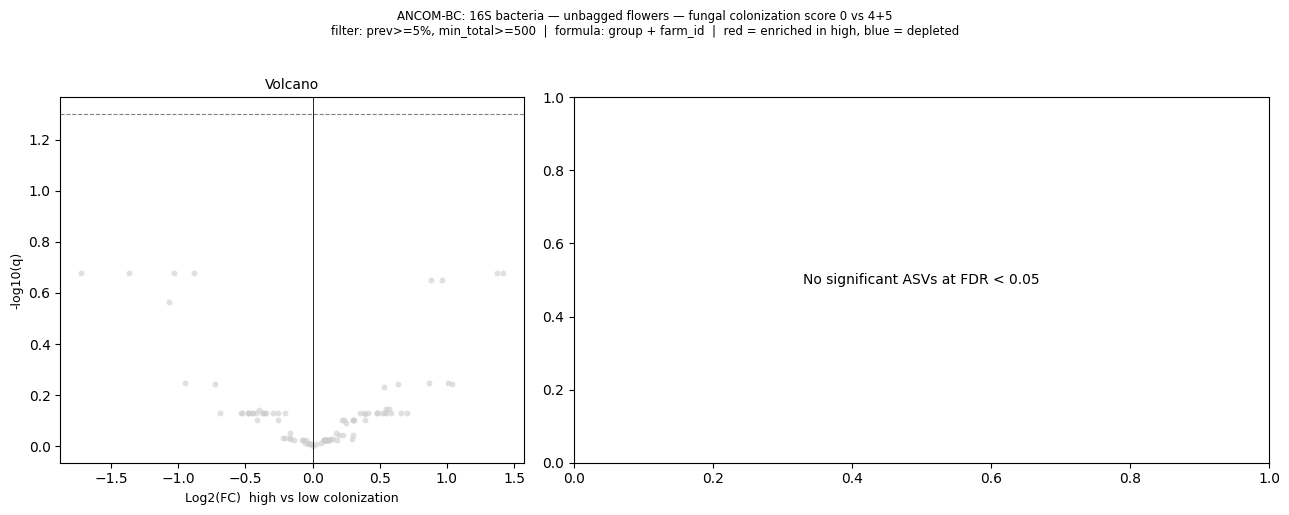

In [5]:
# ── Volcano + lollipop ────────────────────────────────────────────────────────
sig = res_group[res_group['Signif']].sort_values('Log2(FC)')

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, max(5, len(sig) * 0.38 + 2.5)),
    gridspec_kw={'width_ratios': [1, 1.5]}
)

# ── Volcano ───────────────────────────────────────────────────────────────────
ax = axes[0]
ns = res_group[~res_group['Signif']]
s  = res_group[res_group['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue']), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
c_v = ['#D6604D' if v > 0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'],  -np.log10(s['qvalue']),  c=c_v, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(
        row['label'].split('[')[0].strip(),
        xy=(row['Log2(FC)'], -np.log10(row['qvalue'])),
        xytext=(3, 2), textcoords='offset points', fontsize=6
    )
ax.set_xlabel('Log2(FC)  high vs low colonization', fontsize=9)
ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano', fontsize=10)

# ── Lollipop ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
if len(sig) == 0:
    ax2.text(0.5, 0.5, 'No significant ASVs at FDR < ' + str(FDR_ALPHA),
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)
else:
    c_l = ['#D6604D' if v > 0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'], 0, sig['Log2(FC)'], colors=c_l, lw=2, alpha=0.7)
    ax2.scatter(sig['Log2(FC)'], sig['label'], c=c_l, s=55, zorder=3)
    ax2.axvline(0, color='black', lw=0.8)
    for _, row in sig.iterrows():
        ax2.annotate(
            f"q={row['qvalue']:.3f}",
            xy=(row['Log2(FC)'], row['label']),
            xytext=(4, 0), textcoords='offset points', fontsize=6.5, va='center'
        )
    ax2.set_xlabel('Log2(FC)  high vs low colonization', fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR < {FDR_ALPHA}) — genus level', fontsize=10)
    ax2.tick_params(axis='y', labelsize=8)

fig.suptitle(
    'ANCOM-BC: 16S bacteria — unbagged flowers — fungal colonization score 0 vs 4+5\n'
    f'filter: prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}  |  formula: group + farm_id  |  red = enriched in high, blue = depleted',
    fontsize=8.5, y=1.02
)
plt.tight_layout()
fig.savefig(FIG_DIR / '16s_ancombc_colonization_score.pdf', bbox_inches='tight')
plt.show()

---
## ITS1 fungi

In [6]:
# ── Load ITS1 counts + taxonomy ──────────────────────────────────────────────
tbl_its1        = biom.load_table(str(BIOM_DIR / 'cfm_its1_fungi_biosamples_feature-table.biom'))
counts_raw_its1 = tbl_its1.to_dataframe(dense=True)  # ASVs x samples

tax_df_its1 = pd.read_csv(BIOM_DIR / 'cfm_its1_fungi_biosamples_taxonomy.tsv',
                          sep='\t', index_col=0)

def genus_label_its1(asv_id):
    if asv_id not in tax_df_its1.index:
        return asv_id[:8]
    taxon = str(tax_df_its1.loc[asv_id].iloc[0])
    for prefix in ('g__', 'f__', 'o__'):
        for part in reversed(taxon.split(';')):
            name = part.strip().removeprefix(prefix).strip()
            if part.strip().startswith(prefix) and name:
                return f'{name} [{asv_id[:6]}]'
    return asv_id[:8]

# ── 1. Subset (reuse meta_sub from 16S cell) ──────────────────────────────────
shared_its1     = meta_sub.index.intersection(counts_raw_its1.columns)
meta_sub_its1   = meta_sub.loc[shared_its1]
counts_sub_its1 = counts_raw_its1[shared_its1]

# ── 2. Filter WITHIN subset ───────────────────────────────────────────────────
n_sub_its1      = counts_sub_its1.shape[1]
prev_sub_its1   = (counts_sub_its1 > 0).sum(axis=1) / n_sub_its1
table_sub_its1  = counts_sub_its1[
    (prev_sub_its1 >= PREV_THRESHOLD) & (counts_sub_its1.sum(axis=1) >= MIN_TOTAL)
].T  # samples x ASVs

print(f'ITS1 ASVs after filter within subset: {table_sub_its1.shape[1]}')
print(f'  (global filter gave: {(((counts_raw_its1 > 0).sum(axis=1) / counts_raw_its1.shape[1]) >= PREV_THRESHOLD).sum()} ASVs)')


ITS1 ASVs after filter within subset: 244
  (global filter gave: 540 ASVs)


In [7]:
# ── Structural zeros (ITS1) ───────────────────────────────────────────────────
sz_its1     = struc_zero(
    table    = table_sub_its1,
    metadata = meta_sub_its1[['group']],
    grouping = 'group',
    neg_lb   = True
)
sz_any_its1          = sz_its1.any(axis=1)
table_sub_its1_filt  = table_sub_its1.loc[:, ~sz_any_its1]

print(f'Structural zeros: {sz_any_its1.sum()}  '
      f'(in low: {sz_its1["low"].sum()}, in high: {sz_its1["high"].sum()})')
print(f'ASVs passed to ancombc: {table_sub_its1_filt.shape[1]}  (removed {sz_any_its1.sum()})')


Structural zeros: 87  (in low: 30, in high: 73)
ASVs passed to ancombc: 157  (removed 87)


In [8]:
# ── ANCOM-BC (ITS1) ───────────────────────────────────────────────────────────
result_its1 = ancombc(
    table     = table_sub_its1_filt + 1,
    metadata  = meta_sub_its1[['group', 'farm_id']],
    formula   = 'group + farm_id',
    p_adjust  = 'fdr_bh',
    alpha     = FDR_ALPHA,
)

res_group_its1 = result_its1.xs('group[T.high]', level='Covariate').copy()
res_group_its1['label'] = [genus_label_its1(i) for i in res_group_its1.index]

n_sig_its1    = res_group_its1['Signif'].sum()
enriched_its1 = (res_group_its1['Signif'] & (res_group_its1['Log2(FC)'] > 0)).sum()
depleted_its1 = (res_group_its1['Signif'] & (res_group_its1['Log2(FC)'] < 0)).sum()
print(f'Significant (FDR < {FDR_ALPHA}): {n_sig_its1}  '
      f'(enriched in high: {enriched_its1},  depleted: {depleted_its1})')
res_group_its1[res_group_its1['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


Significant (FDR < 0.05): 0  (enriched in high: 0,  depleted: 0)


,label,Log2(FC),SE,W,pvalue,qvalue
FeatureID,,,,,,


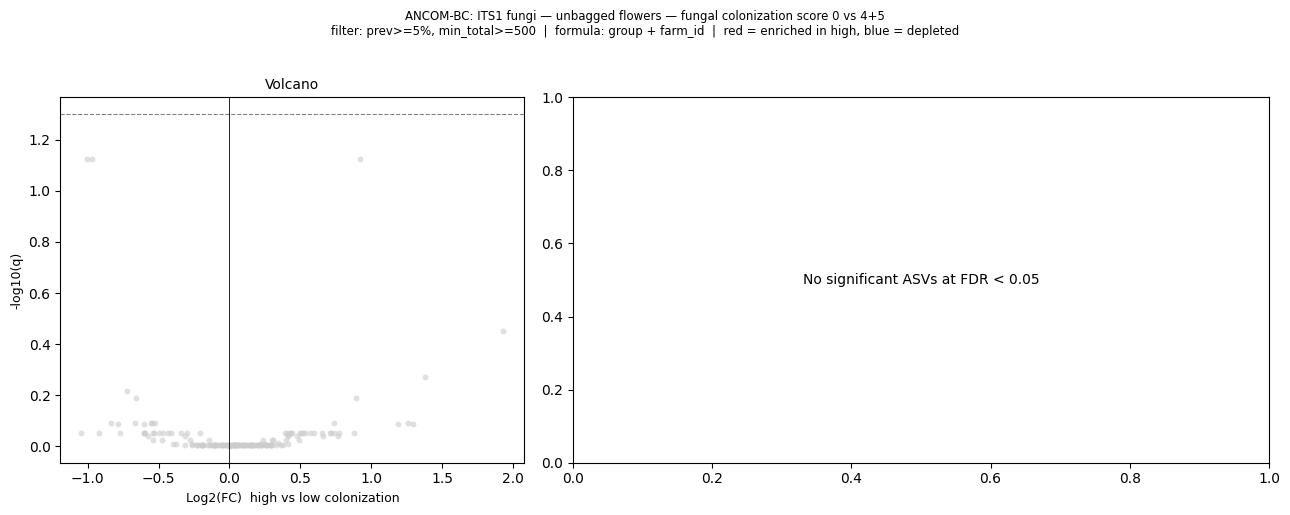

In [9]:
# ── Volcano + lollipop (ITS1) ─────────────────────────────────────────────────
sig_its1 = res_group_its1[res_group_its1['Signif']].sort_values('Log2(FC)')

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, max(5, len(sig_its1) * 0.38 + 2.5)),
    gridspec_kw={'width_ratios': [1, 1.5]}
)

ax = axes[0]
ns = res_group_its1[~res_group_its1['Signif']]
s  = res_group_its1[res_group_its1['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(lower=1e-300)),
           c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
c_v = ['#D6604D' if v > 0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'],  -np.log10(s['qvalue'].clip(lower=1e-300)),
           c=c_v, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'], 1e-300))),
                xytext=(3, 2), textcoords='offset points', fontsize=6)
ax.set_xlabel('Log2(FC)  high vs low colonization', fontsize=9)
ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano', fontsize=10)

ax2 = axes[1]
if len(sig_its1) == 0:
    ax2.text(0.5, 0.5, f'No significant ASVs at FDR < {FDR_ALPHA}',
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)
else:
    c_l = ['#D6604D' if v > 0 else '#4393C3' for v in sig_its1['Log2(FC)']]
    ax2.hlines(sig_its1['label'], 0, sig_its1['Log2(FC)'], colors=c_l, lw=2, alpha=0.7)
    ax2.scatter(sig_its1['Log2(FC)'], sig_its1['label'], c=c_l, s=55, zorder=3)
    ax2.axvline(0, color='black', lw=0.8)
    for _, row in sig_its1.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}",
                     xy=(row['Log2(FC)'], row['label']),
                     xytext=(4, 0), textcoords='offset points', fontsize=6.5, va='center')
    ax2.set_xlabel('Log2(FC)  high vs low colonization', fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR < {FDR_ALPHA}) — genus level', fontsize=10)
    ax2.tick_params(axis='y', labelsize=8)

fig.suptitle(
    'ANCOM-BC: ITS1 fungi — unbagged flowers — fungal colonization score 0 vs 4+5\n'
    f'filter: prev>={PREV_THRESHOLD:.0%}, min_total>={MIN_TOTAL}  |  formula: group + farm_id  |  red = enriched in high, blue = depleted',
    fontsize=8.5, y=1.02
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'its1_ancombc_colonization_score.pdf', bbox_inches='tight')
plt.show()


---
## 2. Sample type: bagged vs unbagged (all biosamples)

In [ ]:
# ── All biosamples: shared data for sections 2 & 3 ──────────────────────────
meta_all = meta[meta['sample_type'].isin(['bagged_flower', 'unbagged_flower'])].copy()
meta_all['sample_type'] = pd.Categorical(
    meta_all['sample_type'], categories=['bagged_flower', 'unbagged_flower'], ordered=False
)

def filter_within(counts_raw, meta_idx):
    """Subset to meta_idx, then filter prev/abund within that subset."""
    shared = meta_idx.intersection(counts_raw.columns)
    sub    = counts_raw[shared]
    n      = sub.shape[1]
    prev   = (sub > 0).sum(axis=1) / n
    filt   = sub[(prev >= PREV_THRESHOLD) & (sub.sum(axis=1) >= MIN_TOTAL)]
    return filt.T, shared  # returns samples x ASVs

table_all_16s,  shared_all_16s  = filter_within(counts_raw,      meta_all.index)
table_all_its1, shared_all_its1 = filter_within(counts_raw_its1, meta_all.index)
meta_all_16s  = meta_all.loc[shared_all_16s]
meta_all_its1 = meta_all.loc[shared_all_its1]

print(f"All biosamples — 16S:  {table_all_16s.shape[0]} samples, {table_all_16s.shape[1]} ASVs")
print(f"All biosamples — ITS1: {table_all_its1.shape[0]} samples, {table_all_its1.shape[1]} ASVs")
print(f"sample_type counts: {meta_all['sample_type'].value_counts().to_dict()}")


In [ ]:
# ── Structural zeros: sample_type (16S) ──────────────────────────────────────
sz_st16 = struc_zero(table_all_16s, meta_all_16s[['sample_type']], grouping='sample_type', neg_lb=True)
sz_st16_any = sz_st16.any(axis=1)
table_st_16s = table_all_16s.loc[:, ~sz_st16_any]
print(f"16S: {sz_st16_any.sum()} structural zeros removed → {table_st_16s.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC: bagged vs unbagged (16S) ───────────────────────────────────────
res_st_16s = ancombc(
    table    = table_st_16s + 1,
    metadata = meta_all_16s[['sample_type']],
    formula  = 'sample_type',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
rg_st_16s = res_st_16s.xs('sample_type[T.unbagged_flower]', level='Covariate').copy()
rg_st_16s['label'] = [genus_label(i) for i in rg_st_16s.index]
sig_n = rg_st_16s['Signif'].sum()
print(f"16S significant (FDR<{FDR_ALPHA}): {sig_n}  "
      f"(enriched unbagged: {(rg_st_16s.Signif & (rg_st_16s['Log2(FC)']>0)).sum()}, "
      f"depleted: {(rg_st_16s.Signif & (rg_st_16s['Log2(FC)']<0)).sum()})")
rg_st_16s[rg_st_16s['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


In [ ]:
# ── Plot: bagged vs unbagged 16S ─────────────────────────────────────────────
sig = rg_st_16s[rg_st_16s['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios':[1,1.5]})
ax = axes[0]
ns = rg_st_16s[~rg_st_16s['Signif']]
s  = rg_st_16s[ rg_st_16s['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v>0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'],  -np.log10(s['qvalue'].clip(1e-300)),  c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'],1e-300))),
                xytext=(3,2), textcoords='offset points', fontsize=6)
ax.set_xlabel('Log2(FC)  unbagged vs bagged', fontsize=9); ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano — 16S', fontsize=10)
ax2 = axes[1]
if len(sig)==0:
    ax2.text(0.5,0.5,f'No significant ASVs at FDR<{FDR_ALPHA}',ha='center',va='center',transform=ax2.transAxes)
else:
    cl = ['#D6604D' if v>0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'],0,sig['Log2(FC)'],colors=cl,lw=2,alpha=0.7)
    ax2.scatter(sig['Log2(FC)'],sig['label'],c=cl,s=55,zorder=3)
    ax2.axvline(0,color='black',lw=0.8)
    for _,row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}",xy=(row['Log2(FC)'],row['label']),
                     xytext=(4,0),textcoords='offset points',fontsize=6.5,va='center')
    ax2.set_xlabel('Log2(FC)  unbagged vs bagged',fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) — genus',fontsize=10)
    ax2.tick_params(axis='y',labelsize=8)
fig.suptitle(f'ANCOM-BC 16S: bagged vs unbagged | formula: sample_type | filter within biosamples',fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'16s_ancombc_sampletype.pdf',bbox_inches='tight'); plt.show()


In [ ]:
# ── Structural zeros: sample_type (ITS1) ─────────────────────────────────────
sz_st_i = struc_zero(table_all_its1, meta_all_its1[['sample_type']], grouping='sample_type', neg_lb=True)
sz_st_i_any = sz_st_i.any(axis=1)
table_st_its1 = table_all_its1.loc[:, ~sz_st_i_any]
print(f"ITS1: {sz_st_i_any.sum()} structural zeros removed → {table_st_its1.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC: bagged vs unbagged (ITS1) ──────────────────────────────────────
res_st_its1 = ancombc(
    table    = table_st_its1 + 1,
    metadata = meta_all_its1[['sample_type']],
    formula  = 'sample_type',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
rg_st_its1 = res_st_its1.xs('sample_type[T.unbagged_flower]', level='Covariate').copy()
rg_st_its1['label'] = [genus_label_its1(i) for i in rg_st_its1.index]
sig_n = rg_st_its1['Signif'].sum()
print(f"ITS1 significant (FDR<{FDR_ALPHA}): {sig_n}  "
      f"(enriched unbagged: {(rg_st_its1.Signif & (rg_st_its1['Log2(FC)']>0)).sum()}, "
      f"depleted: {(rg_st_its1.Signif & (rg_st_its1['Log2(FC)']<0)).sum()})")
rg_st_its1[rg_st_its1['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


In [ ]:
# ── Plot: bagged vs unbagged ITS1 ────────────────────────────────────────────
sig = rg_st_its1[rg_st_its1['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios':[1,1.5]})
ax = axes[0]
ns = rg_st_its1[~rg_st_its1['Signif']]
s  = rg_st_its1[ rg_st_its1['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v>0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'],  -np.log10(s['qvalue'].clip(1e-300)),  c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'],1e-300))),
                xytext=(3,2), textcoords='offset points', fontsize=6)
ax.set_xlabel('Log2(FC)  unbagged vs bagged', fontsize=9); ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano — ITS1', fontsize=10)
ax2 = axes[1]
if len(sig)==0:
    ax2.text(0.5,0.5,f'No significant ASVs at FDR<{FDR_ALPHA}',ha='center',va='center',transform=ax2.transAxes)
else:
    cl = ['#D6604D' if v>0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'],0,sig['Log2(FC)'],colors=cl,lw=2,alpha=0.7)
    ax2.scatter(sig['Log2(FC)'],sig['label'],c=cl,s=55,zorder=3)
    ax2.axvline(0,color='black',lw=0.8)
    for _,row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}",xy=(row['Log2(FC)'],row['label']),
                     xytext=(4,0),textcoords='offset points',fontsize=6.5,va='center')
    ax2.set_xlabel('Log2(FC)  unbagged vs bagged',fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) — genus',fontsize=10)
    ax2.tick_params(axis='y',labelsize=8)
fig.suptitle(f'ANCOM-BC ITS1: bagged vs unbagged | formula: sample_type | filter within biosamples',fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'its1_ancombc_sampletype.pdf',bbox_inches='tight'); plt.show()


---
## 3. Farm comparison — global test across all farms

In [ ]:
# ── Structural zeros: farm_id (16S) ──────────────────────────────────────────
sz_farm16 = struc_zero(table_all_16s, meta_all_16s[['farm_id']], grouping='farm_id', neg_lb=True)
sz_farm16_any = sz_farm16.any(axis=1)
table_farm_16s = table_all_16s.loc[:, ~sz_farm16_any]
print(f"16S: {sz_farm16_any.sum()} structural zeros removed → {table_farm_16s.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC global test: farm_id (16S) ──────────────────────────────────────
# grouping parameter triggers global test; returns (res_main, res_global)
ancom_farm16_out = ancombc(
    table    = table_farm_16s + 1,
    metadata = meta_all_16s[['farm_id']],
    formula  = 'farm_id',
    grouping = 'farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
res_main_farm16, res_global_farm16 = ancom_farm16_out if isinstance(ancom_farm16_out, tuple) else (ancom_farm16_out, None)
if res_global_farm16 is None and hasattr(res_main_farm16, '_fields'):
    res_main_farm16, res_global_farm16 = res_main_farm16[0], res_main_farm16[1]

res_global_farm16['label'] = [genus_label(i) for i in res_global_farm16.index]
sig_n = res_global_farm16['Signif'].sum()
print(f"16S global test — significant across farms (FDR<{FDR_ALPHA}): {sig_n}")
res_global_farm16[res_global_farm16['Signif']].sort_values('W', ascending=False)[['label','W','pvalue','qvalue']]


In [ ]:
# ── Plot: farm global test 16S — top 30 significant ASVs by W-statistic ──────
sig = res_global_farm16[res_global_farm16['Signif']].sort_values('W', ascending=False).head(30)
fig, ax = plt.subplots(figsize=(8, max(4, len(sig)*0.35+1.5)))
if len(sig) == 0:
    ax.text(0.5,0.5,f'No significant ASVs at FDR<{FDR_ALPHA}',ha='center',va='center',transform=ax.transAxes)
else:
    sig_plot = sig.sort_values('W')
    ax.barh(sig_plot['label'], sig_plot['W'], color='#5A9BD5', alpha=0.8)
    ax.set_xlabel('W-statistic (global test)', fontsize=9)
    ax.set_title(f'Top {len(sig)} ASVs differing across farms (FDR<{FDR_ALPHA})', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    for i, (_, row) in enumerate(sig_plot.iterrows()):
        ax.annotate(f"q={row['qvalue']:.3f}", xy=(row['W'], row['label']),
                    xytext=(2,0), textcoords='offset points', fontsize=6, va='center')
fig.suptitle('ANCOM-BC 16S: global test across farms | formula: farm_id | all biosamples',fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'16s_ancombc_farm_global.pdf',bbox_inches='tight'); plt.show()


In [ ]:
# ── Structural zeros: farm_id (ITS1) ─────────────────────────────────────────
sz_farm_i = struc_zero(table_all_its1, meta_all_its1[['farm_id']], grouping='farm_id', neg_lb=True)
sz_farm_i_any = sz_farm_i.any(axis=1)
table_farm_its1 = table_all_its1.loc[:, ~sz_farm_i_any]
print(f"ITS1: {sz_farm_i_any.sum()} structural zeros removed → {table_farm_its1.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC global test: farm_id (ITS1) ─────────────────────────────────────
ancom_farm_i_out = ancombc(
    table    = table_farm_its1 + 1,
    metadata = meta_all_its1[['farm_id']],
    formula  = 'farm_id',
    grouping = 'farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
res_main_farm_i, res_global_farm_i = ancom_farm_i_out if isinstance(ancom_farm_i_out, tuple) else (ancom_farm_i_out, None)
if res_global_farm_i is None and hasattr(res_main_farm_i, '_fields'):
    res_main_farm_i, res_global_farm_i = res_main_farm_i[0], res_main_farm_i[1]

res_global_farm_i['label'] = [genus_label_its1(i) for i in res_global_farm_i.index]
sig_n = res_global_farm_i['Signif'].sum()
print(f"ITS1 global test — significant across farms (FDR<{FDR_ALPHA}): {sig_n}")
res_global_farm_i[res_global_farm_i['Signif']].sort_values('W', ascending=False)[['label','W','pvalue','qvalue']]


In [ ]:
# ── Plot: farm global test ITS1 ───────────────────────────────────────────────
sig = res_global_farm_i[res_global_farm_i['Signif']].sort_values('W', ascending=False).head(30)
fig, ax = plt.subplots(figsize=(8, max(4, len(sig)*0.35+1.5)))
if len(sig) == 0:
    ax.text(0.5,0.5,f'No significant ASVs at FDR<{FDR_ALPHA}',ha='center',va='center',transform=ax.transAxes)
else:
    sig_plot = sig.sort_values('W')
    ax.barh(sig_plot['label'], sig_plot['W'], color='#DD8452', alpha=0.8)
    ax.set_xlabel('W-statistic (global test)', fontsize=9)
    ax.set_title(f'Top {len(sig)} ASVs differing across farms (FDR<{FDR_ALPHA})', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    for i, (_, row) in enumerate(sig_plot.iterrows()):
        ax.annotate(f"q={row['qvalue']:.3f}", xy=(row['W'], row['label']),
                    xytext=(2,0), textcoords='offset points', fontsize=6, va='center')
fig.suptitle('ANCOM-BC ITS1: global test across farms | formula: farm_id | all biosamples',fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'its1_ancombc_farm_global.pdf',bbox_inches='tight'); plt.show()


---
## 4. Pollination (is_pollination_clsm: 0 vs 1)

All biosamples with non-NA pollination status.  
Formula: `is_pollination_clsm + sample_type + farm_id`  
(sample_type included to separate bagging effect from pollination effect)

In [ ]:
# ── Subset: all biosamples with non-NA is_pollination_clsm ───────────────────
meta_poll = meta[
    (meta['sample_type'].isin(['bagged_flower', 'unbagged_flower'])) &
    (meta['is_pollination_clsm'].notna())
].copy()
meta_poll['is_pollination_clsm'] = pd.Categorical(
    meta_poll['is_pollination_clsm'].astype(int).astype(str),
    categories=['0', '1'], ordered=False   # 0 = reference
)

table_poll_16s,  shared_poll_16s  = filter_within(counts_raw,      meta_poll.index)
table_poll_its1, shared_poll_its1 = filter_within(counts_raw_its1, meta_poll.index)
meta_poll_16s  = meta_poll.loc[shared_poll_16s]
meta_poll_its1 = meta_poll.loc[shared_poll_its1]

print(f"Pollination subset — 16S:  {table_poll_16s.shape[0]} samples, {table_poll_16s.shape[1]} ASVs")
print(f"Pollination subset — ITS1: {table_poll_its1.shape[0]} samples, {table_poll_its1.shape[1]} ASVs")
print(f"is_pollination_clsm: {meta_poll['is_pollination_clsm'].value_counts().to_dict()}")
print(f"sample_type: {meta_poll['sample_type'].value_counts().to_dict()}")


In [ ]:
sz_p16 = struc_zero(table_poll_16s, meta_poll_16s[['is_pollination_clsm']],
                    grouping='is_pollination_clsm', neg_lb=True)
sz_p16_any      = sz_p16.any(axis=1)
table_poll_16s_f = table_poll_16s.loc[:, ~sz_p16_any]
print(f"16S: {sz_p16_any.sum()} structural zeros removed → {table_poll_16s_f.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC: pollination (16S) ───────────────────────────────────────────────
res_poll_16s = ancombc(
    table    = table_poll_16s_f + 1,
    metadata = meta_poll_16s[['is_pollination_clsm', 'sample_type', 'farm_id']],
    formula  = 'is_pollination_clsm + sample_type + farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
covariates_poll_16s = res_poll_16s.index.get_level_values('Covariate').unique().tolist()
print("Covariates:", covariates_poll_16s)
poll_cov_16s = 'is_pollination_clsm'  # patsy treats numeric 0/1 as continuous -- no [T.x] suffix
print("Using:", poll_cov_16s)
rg_poll_16s = res_poll_16s.xs(poll_cov_16s, level='Covariate').copy()
rg_poll_16s['label'] = [genus_label(i) for i in rg_poll_16s.index]
sig_n = rg_poll_16s['Signif'].sum()
print(f"16S significant (FDR<{FDR_ALPHA}): {sig_n}  "
      f"(enriched pollinated: {(rg_poll_16s.Signif & (rg_poll_16s['Log2(FC)']>0)).sum()}, "
      f"depleted: {(rg_poll_16s.Signif & (rg_poll_16s['Log2(FC)']<0)).sum()})")
rg_poll_16s[rg_poll_16s['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


In [ ]:
sig = rg_poll_16s[rg_poll_16s['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios':[1,1.5]})
ax = axes[0]
ns,s = rg_poll_16s[~rg_poll_16s['Signif']], rg_poll_16s[rg_poll_16s['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v>0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'], -np.log10(s['qvalue'].clip(1e-300)), c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8); ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'],1e-300))),
                xytext=(3,2), textcoords='offset points', fontsize=6)
ax.set_xlabel('Log2(FC)  pollinated vs not', fontsize=9); ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano — 16S', fontsize=10)
ax2 = axes[1]
if len(sig)==0:
    ax2.text(0.5,0.5,f'No significant ASVs',ha='center',va='center',transform=ax2.transAxes)
else:
    cl=['#D6604D' if v>0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'],0,sig['Log2(FC)'],colors=cl,lw=2,alpha=0.7)
    ax2.scatter(sig['Log2(FC)'],sig['label'],c=cl,s=55,zorder=3)
    ax2.axvline(0,color='black',lw=0.8)
    for _,row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}",xy=(row['Log2(FC)'],row['label']),
                     xytext=(4,0),textcoords='offset points',fontsize=6.5,va='center')
    ax2.set_xlabel('Log2(FC)  pollinated vs not',fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) — genus',fontsize=10)
    ax2.tick_params(axis='y',labelsize=8)
fig.suptitle('ANCOM-BC 16S: pollination (CLSM 0 vs 1) | formula: is_pollination_clsm + sample_type + farm_id',
             fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'16s_ancombc_pollination.pdf',bbox_inches='tight'); plt.show()


In [ ]:
sz_p_i = struc_zero(table_poll_its1, meta_poll_its1[['is_pollination_clsm']],
                    grouping='is_pollination_clsm', neg_lb=True)
sz_p_i_any       = sz_p_i.any(axis=1)
table_poll_its1_f = table_poll_its1.loc[:, ~sz_p_i_any]
print(f"ITS1: {sz_p_i_any.sum()} structural zeros removed → {table_poll_its1_f.shape[1]} ASVs")


In [ ]:
# ── ANCOM-BC: pollination (ITS1) ──────────────────────────────────────────────
res_poll_its1 = ancombc(
    table    = table_poll_its1_f + 1,
    metadata = meta_poll_its1[['is_pollination_clsm', 'sample_type', 'farm_id']],
    formula  = 'is_pollination_clsm + sample_type + farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)
covariates_poll_its1 = res_poll_its1.index.get_level_values('Covariate').unique().tolist()
print("Covariates:", covariates_poll_its1)
poll_cov_its1 = 'is_pollination_clsm'  # patsy treats numeric 0/1 as continuous -- no [T.x] suffix
print("Using:", poll_cov_its1)
rg_poll_its1 = res_poll_its1.xs(poll_cov_its1, level='Covariate').copy()
rg_poll_its1['label'] = [genus_label_its1(i) for i in rg_poll_its1.index]
sig_n = rg_poll_its1['Signif'].sum()
print(f"ITS1 significant (FDR<{FDR_ALPHA}): {sig_n}  "
      f"(enriched pollinated: {(rg_poll_its1.Signif & (rg_poll_its1['Log2(FC)']>0)).sum()}, "
      f"depleted: {(rg_poll_its1.Signif & (rg_poll_its1['Log2(FC)']<0)).sum()})")
rg_poll_its1[rg_poll_its1['Signif']].sort_values('Log2(FC)')[['label','Log2(FC)','SE','W','pvalue','qvalue']]


In [ ]:
sig = rg_poll_its1[rg_poll_its1['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios':[1,1.5]})
ax = axes[0]
ns,s = rg_poll_its1[~rg_poll_its1['Signif']], rg_poll_its1[rg_poll_its1['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v>0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'], -np.log10(s['qvalue'].clip(1e-300)), c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8); ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'],1e-300))),
                xytext=(3,2), textcoords='offset points', fontsize=6)
ax.set_xlabel('Log2(FC)  pollinated vs not', fontsize=9); ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano — ITS1', fontsize=10)
ax2 = axes[1]
if len(sig)==0:
    ax2.text(0.5,0.5,f'No significant ASVs',ha='center',va='center',transform=ax2.transAxes)
else:
    cl=['#D6604D' if v>0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'],0,sig['Log2(FC)'],colors=cl,lw=2,alpha=0.7)
    ax2.scatter(sig['Log2(FC)'],sig['label'],c=cl,s=55,zorder=3)
    ax2.axvline(0,color='black',lw=0.8)
    for _,row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}",xy=(row['Log2(FC)'],row['label']),
                     xytext=(4,0),textcoords='offset points',fontsize=6.5,va='center')
    ax2.set_xlabel('Log2(FC)  pollinated vs not',fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) — genus',fontsize=10)
    ax2.tick_params(axis='y',labelsize=8)
fig.suptitle('ANCOM-BC ITS1: pollination (CLSM 0 vs 1) | formula: is_pollination_clsm + sample_type + farm_id',
             fontsize=9,y=1.01)
plt.tight_layout(); fig.savefig(FIG_DIR/'its1_ancombc_pollination.pdf',bbox_inches='tight'); plt.show()


---
## Section 5 — Effective pollination: unbagged only, pi=0 vs pi>threshold

**Hypothesis:** flowers with high pollen-intensity (`pi_clsm > PI_THRESH`) received visits from
*effective* pollinators (abundant pollen deposition) and may carry a distinct pollinator-associated
microbiome compared to confirmed-unpollinated flowers.

**Groups (unbagged_flower only):**
- **control**: `is_pollination_clsm == 0` AND `pi_clsm == 0` (confirmed not pollinated)
- **hi-pi**: `is_pollination_clsm == 1` AND `pi_clsm > PI_THRESH` (abundant pollen)

Low-PI samples (1 <= pi_clsm <= PI_THRESH) are *excluded* to sharpen the contrast.
No `sample_type` covariate needed — all samples are `unbagged_flower`.

In [ ]:
# ── Section 5 parameter ───────────────────────────────────────────────────────
PI_THRESH = 10  # pollen intensity threshold; change to explore other cutoffs

# ── Subset: unbagged flowers, clear pollination status only ──────────────────
meta_eff_raw = meta[
    (meta['sample_type'] == 'unbagged_flower')
].copy()
meta_eff_raw['pi_clsm_num'] = pd.to_numeric(meta_eff_raw['pi_clsm'],             errors='coerce')
meta_eff_raw['is_poll_num'] = pd.to_numeric(meta_eff_raw['is_pollination_clsm'], errors='coerce')

ctrl_mask = (meta_eff_raw['is_poll_num'] == 0) & (meta_eff_raw['pi_clsm_num'] == 0)
hipi_mask = (meta_eff_raw['is_poll_num'] == 1) & (meta_eff_raw['pi_clsm_num'] > PI_THRESH)

meta_eff = meta_eff_raw[ctrl_mask | hipi_mask].copy()
meta_eff['poll_group'] = pd.Categorical(
    ['control' if ctrl_mask.loc[i] else 'hi-pi' for i in meta_eff.index],
    categories=['control', 'hi-pi'],  # 'control' is reference
    ordered=False,
)

print(f'PI_THRESH = {PI_THRESH}')
print(f'Effective pollination subset: {len(meta_eff)} samples')
print('poll_group:', meta_eff['poll_group'].value_counts().to_dict())
print('\nfarm_id x poll_group:')
print(meta_eff.groupby(['farm_id', 'poll_group']).size().unstack(fill_value=0))

In [ ]:
# ── ANCOM-BC: effective pollination (16S) ─────────────────────────────────────
table_eff_16s, shared_eff_16s = filter_within(counts_raw, meta_eff.index)
meta_eff_16s = meta_eff.loc[shared_eff_16s]

print(f'16S after filter: {table_eff_16s.shape[0]} samples, {table_eff_16s.shape[1]} ASVs')
print('poll_group:', meta_eff_16s['poll_group'].value_counts().to_dict())

sz_eff_16s = struc_zero(
    table_eff_16s,
    meta_eff_16s[['poll_group']],
    grouping='poll_group',
    neg_lb=True,
)
print('Structural zeros (16S):', sz_eff_16s.sum())

res_eff_16s = ancombc(
    table    = table_eff_16s + 1,
    metadata = meta_eff_16s[['poll_group', 'farm_id']],
    formula  = 'poll_group + farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)

covs_eff_16s = res_eff_16s.index.get_level_values('Covariate').unique().tolist()
print('Covariates:', covs_eff_16s)
# poll_group is pd.Categorical(['control','hi-pi']) -> patsy encodes as 'poll_group[T.hi-pi]'
eff_cov_16s = 'poll_group[T.hi-pi]'
rg_eff_16s = res_eff_16s.xs(eff_cov_16s, level='Covariate').copy()
rg_eff_16s['label'] = [genus_label(i) for i in rg_eff_16s.index]
print(f'Significant 16S ASVs: {rg_eff_16s["Signif"].sum()}')

In [ ]:
sig = rg_eff_16s[rg_eff_16s['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios': [1, 1.5]})
ax = axes[0]
ns, s = rg_eff_16s[~rg_eff_16s['Signif']], rg_eff_16s[rg_eff_16s['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v > 0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'], -np.log10(s['qvalue'].clip(1e-300)), c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'], 1e-300))),
                xytext=(3, 2), textcoords='offset points', fontsize=6)
ax.set_xlabel(f'Log2(FC)  hi-pi (>{PI_THRESH}) vs control', fontsize=9)
ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano -- 16S', fontsize=10)
ax2 = axes[1]
if len(sig) == 0:
    ax2.text(0.5, 0.5, 'No significant ASVs', ha='center', va='center', transform=ax2.transAxes)
else:
    cl = ['#D6604D' if v > 0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'], 0, sig['Log2(FC)'], colors=cl, lw=2, alpha=0.7)
    ax2.scatter(sig['Log2(FC)'], sig['label'], c=cl, s=55, zorder=3)
    ax2.axvline(0, color='black', lw=0.8)
    for _, row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}", xy=(row['Log2(FC)'], row['label']),
                     xytext=(4, 0), textcoords='offset points', fontsize=6.5, va='center')
    ax2.set_xlabel(f'Log2(FC)  hi-pi (>{PI_THRESH}) vs control', fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) -- genus', fontsize=10)
    ax2.tick_params(axis='y', labelsize=8)
n_ctrl = (meta_eff_16s['poll_group'] == 'control').sum()
n_hipi = (meta_eff_16s['poll_group'] == 'hi-pi').sum()
fig.suptitle(
    f'ANCOM-BC 16S: effective pollination (pi_clsm>{PI_THRESH}) | '
    f'unbagged only | n=ctrl:{n_ctrl} hi-pi:{n_hipi}',
    fontsize=9, y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / f'16s_ancombc_effpoll_pi{PI_THRESH}.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ── ANCOM-BC: effective pollination (ITS1) ────────────────────────────────────
table_eff_its1, shared_eff_its1 = filter_within(counts_raw_its1, meta_eff.index)
meta_eff_its1 = meta_eff.loc[shared_eff_its1]

print(f'ITS1 after filter: {table_eff_its1.shape[0]} samples, {table_eff_its1.shape[1]} ASVs')
print('poll_group:', meta_eff_its1['poll_group'].value_counts().to_dict())

sz_eff_its1 = struc_zero(
    table_eff_its1,
    meta_eff_its1[['poll_group']],
    grouping='poll_group',
    neg_lb=True,
)
print('Structural zeros (ITS1):', sz_eff_its1.sum())

res_eff_its1 = ancombc(
    table    = table_eff_its1 + 1,
    metadata = meta_eff_its1[['poll_group', 'farm_id']],
    formula  = 'poll_group + farm_id',
    p_adjust = 'fdr_bh',
    alpha    = FDR_ALPHA,
)

covs_eff_its1 = res_eff_its1.index.get_level_values('Covariate').unique().tolist()
print('Covariates:', covs_eff_its1)
# poll_group is pd.Categorical(['control','hi-pi']) -> patsy encodes as 'poll_group[T.hi-pi]'
eff_cov_its1 = 'poll_group[T.hi-pi]'
rg_eff_its1 = res_eff_its1.xs(eff_cov_its1, level='Covariate').copy()
rg_eff_its1['label'] = [genus_label_its1(i) for i in rg_eff_its1.index]
print(f'Significant ITS1 ASVs: {rg_eff_its1["Signif"].sum()}')

In [ ]:
sig = rg_eff_its1[rg_eff_its1['Signif']].sort_values('Log2(FC)')
fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(sig)*0.38+2.5)),
                         gridspec_kw={'width_ratios': [1, 1.5]})
ax = axes[0]
ns, s = rg_eff_its1[~rg_eff_its1['Signif']], rg_eff_its1[rg_eff_its1['Signif']]
ax.scatter(ns['Log2(FC)'], -np.log10(ns['qvalue'].clip(1e-300)), c='#CCCCCC', s=18, alpha=0.6, linewidths=0)
cv = ['#D6604D' if v > 0 else '#4393C3' for v in s['Log2(FC)']]
ax.scatter(s['Log2(FC)'], -np.log10(s['qvalue'].clip(1e-300)), c=cv, s=45, linewidths=0.4, edgecolors='black')
ax.axhline(-np.log10(FDR_ALPHA), color='grey', ls='--', lw=0.8)
ax.axvline(0, color='black', lw=0.6)
for _, row in s.iterrows():
    ax.annotate(row['label'].split('[')[0].strip(),
                xy=(row['Log2(FC)'], -np.log10(max(row['qvalue'], 1e-300))),
                xytext=(3, 2), textcoords='offset points', fontsize=6)
ax.set_xlabel(f'Log2(FC)  hi-pi (>{PI_THRESH}) vs control', fontsize=9)
ax.set_ylabel('-log10(q)', fontsize=9)
ax.set_title('Volcano -- ITS1', fontsize=10)
ax2 = axes[1]
if len(sig) == 0:
    ax2.text(0.5, 0.5, 'No significant ASVs', ha='center', va='center', transform=ax2.transAxes)
else:
    cl = ['#D6604D' if v > 0 else '#4393C3' for v in sig['Log2(FC)']]
    ax2.hlines(sig['label'], 0, sig['Log2(FC)'], colors=cl, lw=2, alpha=0.7)
    ax2.scatter(sig['Log2(FC)'], sig['label'], c=cl, s=55, zorder=3)
    ax2.axvline(0, color='black', lw=0.8)
    for _, row in sig.iterrows():
        ax2.annotate(f"q={row['qvalue']:.3f}", xy=(row['Log2(FC)'], row['label']),
                     xytext=(4, 0), textcoords='offset points', fontsize=6.5, va='center')
    ax2.set_xlabel(f'Log2(FC)  hi-pi (>{PI_THRESH}) vs control', fontsize=9)
    ax2.set_title(f'Significant ASVs (FDR<{FDR_ALPHA}) -- genus', fontsize=10)
    ax2.tick_params(axis='y', labelsize=8)
n_ctrl = (meta_eff_its1['poll_group'] == 'control').sum()
n_hipi = (meta_eff_its1['poll_group'] == 'hi-pi').sum()
fig.suptitle(
    f'ANCOM-BC ITS1: effective pollination (pi_clsm>{PI_THRESH}) | '
    f'unbagged only | n=ctrl:{n_ctrl} hi-pi:{n_hipi}',
    fontsize=9, y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / f'its1_ancombc_effpoll_pi{PI_THRESH}.pdf', bbox_inches='tight')
plt.show()